# Is the "kicker" really a violent, reliable turn? 🥾
### A famous candlestick pattern — two big candles and a gap — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gap-reversal forecasts%3F: Busted](https://img.shields.io/badge/Gap--reversal_forecasts%3F-Busted-8b949e?style=flat-square)

Open any candlestick guide and you'll meet the **kicker**: a strong down candle, then a strong up candle that **gaps up** the very next day (or the mirror, to the downside). Two opposite *marubozu* candles — big bodies, almost no wicks — split by a gap **in the new direction**. The lore, repeated everywhere, is that the kicker **ignores the prior trend** and marks one of the most *reliable* reversals on the chart: when it prints, you trade its direction, no questions asked.

It *looks* decisive on a hand-picked chart — a wall of red, then a gap and a wall of green. But "looks decisive" is exactly how charts fool us. So we did the only fair thing: encode the kicker **mechanically** (a real marubozu test, a real gap test, no eyeballing), fire the rule across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **entering on random days, in the same long/short mix.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kicker_pattern import data, strategy as st

ASOF = "2026-05-31"
BF = 0.60
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real kicker cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 80, 'n_bull': 43, 'n_bear': 37, 'body_frac': 0.6, 'fp_spy': '4cb5244f3990', 'h5': (5, 80, -7.1, 49, -0.2, 30.6, -37.7, -9.1, -0.96, 0.339), 'h10': (10, 80, -17.8, 46, -0.43, 37.4, -55.2, -19.8, -1.13, 0.26), 'h20': (20, 80, -19.1, 51, -0.35, 34.5, -53.5, -21.1, -0.78, 0.438), 'h60': (60, 78, 13.6, 54, 0.11, 34.5, -20.9, 11.6, -0.15, 0.878), 'per': [('SPY', 13, 121.7, 0.82, 45.9, 75.8), ('QQQ', 16, 147.5, 1.03, 77.9, 69.5), ('IWM', 5, -385.2, None, 20.6, -405.9), ('DIA', 12, -76.0, -0.44, -2.1, -73.9), ('GLD', 34, -77.3, -1.38, 30.0, -107.3)], 'placebo': [('SPY', 121.7, 0.002), ('QQQ', 147.5, 0.002), ('IWM', -385.2, 1.0), ('DIA', -76.0, 0.996), ('GLD', -77.3, 0.976)], 'syn': [(0.0, 156, 0.6, 49, 0.02), (0.6, 156, 547.4, 79, 10.35)]}


real kicker cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I trade the kicker's direction, do I make money? | **No — barely break-even, and *worse* than random.** The win-rate is ~50% and the average trade is slightly negative at 5–20 days. |
| Is it *the kicker* doing anything? | **No.** Enter on **random days** in the same long/short mix and you do **better** — by 38–55 bps at 5–20 days. |
| Does the gap-reversal forecast? | **Not coherently.** Scramble the gap geometry and the result is a mess: where the kicker looks 'good' it's two noisy small samples that *still* lose to random; everywhere else the geometry is useless. |
| So is it a tradable edge? | **No.** It's a vivid *name* for two big candles and a gap — not a turn predictor. And it prints only ~4×/year per index, so there's barely anything to trade even if it worked. |

> The kicker is a great way to *describe* a violent two-day move after the fact. As a *forecast* — "the turn will continue" — it's a **mirage**: a 50/50 coin with a small negative tilt, beaten by throwing darts.

## 1 · The claim

> *"Two opposite **marubozu** candles (big body, no wicks) separated by a **gap in the new direction**. A bullish kicker = a down marubozu, then an up marubozu gapping up; a bearish kicker = the mirror. It **ignores the prior trend** and marks a violent, reliable reversal. Trade its direction."*

This is a staple of **Steve Nison's** candlestick canon, and **Thomas Bulkowski's** *Encyclopedia of Candlestick Charts* ranks the kicker near the top for reversal frequency. It's built into every charting suite's pattern scanner — so: does the gap really kick?

## 2 · So what?

If the kicker genuinely *forecast* the next move, it would be remarkable: two candles and a gap predicting a multi-week direction, a clean crack in market efficiency you could trade on sight. That's the promise.

But there are two traps. **(a)** It's a *reversal* pattern read on a market that drifts **up** over time — so a bullish kicker (a long) gets the drift for free, while a bearish kicker (a short) fights it; you have to neutralise that. **(b)** Bulkowski's famous 'reliable' stat is an **unconditional** reversal frequency, never raced against random entries. To separate the **pattern** from the **tide**, we draw the kicker by a fixed rule and compare it to **random days in the same long/short mix.** We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Define a marubozu mechanically.** A candle whose **body is ≥ 60% of its range** — a strong candle with tiny wicks. No eyeballing.
2. **Define the kicker by rule.** Yesterday and today are **opposite-colour** marubozus, and today **gaps in its own direction** past yesterday's open. Read on today's close — no future data.
3. **Trade the lore.** Long a bullish kicker, short a bearish one, entered at the **next close**; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**, in the **same long/short mix**. If the kicker matters, it must beat random. *If it doesn't, the pattern is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical kicker even look like? Here's SPY with the kickers the rule fires — green up-arrows for bullish, red down-arrows for bearish.

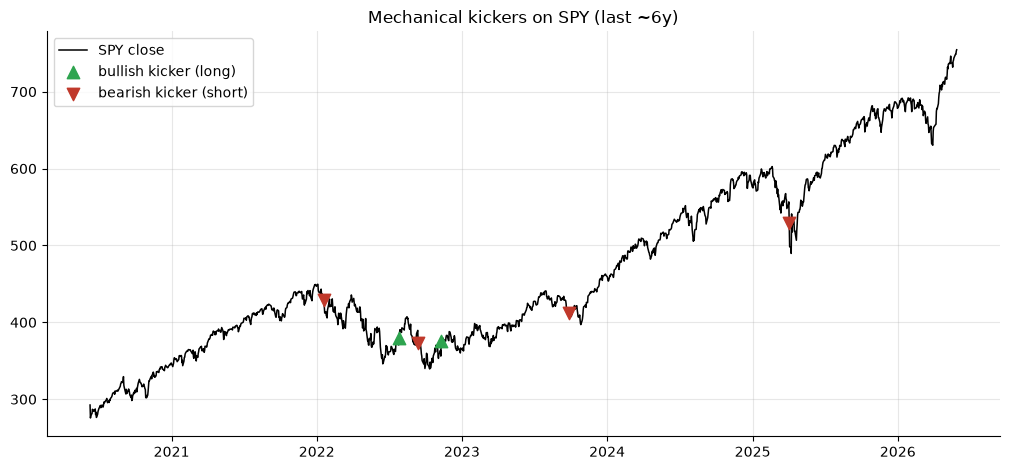

kickers in window: bull 2 | bear 4


In [2]:
if HAVE_REAL:
    b = load('SPY'); cl = b['close']
    sig = st.kicker_signals(b, body_frac=BF)
    seg = cl.iloc[-1500:]
    bull = sig[(sig>0) & (sig.index>=seg.index[0])].index
    bear = sig[(sig<0) & (sig.index>=seg.index[0])].index
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter(bull, cl.reindex(bull), marker='^', c=GREEN, s=80, zorder=5, label='bullish kicker (long)')
    ax.scatter(bear, cl.reindex(bear), marker='v', c=RED, s=80, zorder=5, label='bearish kicker (short)')
    ax.set_title('Mechanical kickers on SPY (last ~6y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('kickers in window: bull', len(bull), '| bear', len(bear))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Strict marubozu+gap kickers are **rare** — only ~80 across five tapes in 21 years (43 bullish, 37 bearish). That rarity is itself a finding. Now the real question: do those arrows mark turns? **Let's race the kicker against random entries** at four horizons. Blue = trade the kicker; grey = random days, same long/short mix.

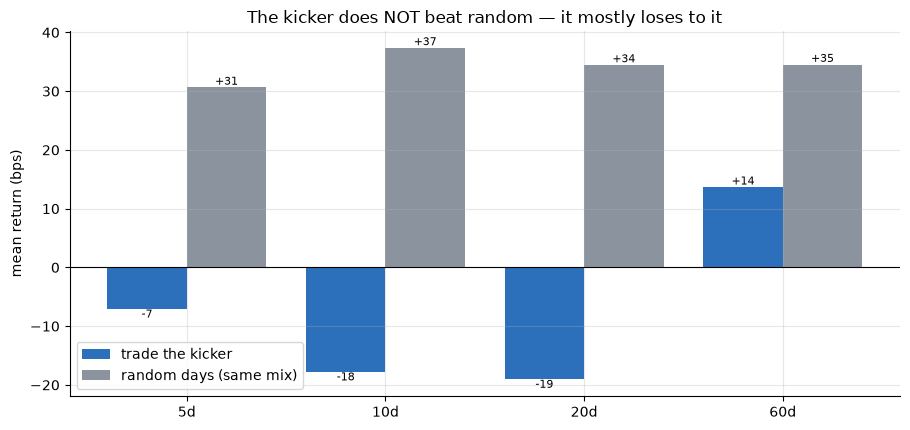

kicker: [-7, -18, -19, 14]
random: [31, 37, 34, 35]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    kick, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t)
            e, dirs = st.kicker_entries(b, body_frac=BF)
            re, rdir = st.random_entries(b, max(len(e),50), dirs=dirs, seed=7)
            tt.append(st.forward_returns(b, e, dirs, h)); rr.append(st.forward_returns(b, re, rdir, h))
        kick.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    kick = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, kick, .4, color='#2c6fbb', label='trade the kicker')
ax.bar(x+.2, rnd, .4, color=GREY, label='random days (same mix)')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(kick,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The kicker does NOT beat random — it mostly loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('kicker:', [round(v) for v in kick]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The kicker is roughly **flat-to-negative** (−7 / −18 / −19 bps at 5/10/20 days) while plain **random entries make +30 to +37 bps**. At every horizon the famous kicker is *worse* than throwing darts. The pattern isn't marking a turn — it's a 50/50 coin with a small negative tilt.

**One more sanity check.** What if we scramble the kicker's *gap geometry* — keep the same big candles but randomise which way the gaps point? If price really 'respects the gap', the nonsense version should do much worse.

In [4]:
if HAVE_REAL:
    rows = []
    for t in data.DEFAULT_TICKERS:
        pl = st.gap_scramble_placebo(load(t), 20, body_frac=BF, n_draws=200, seed=457)
        rows.append((t, pl['obs']*1e4, pl['p_value']))
else:
    rows = [(t, o, p) for (t,o,p) in R['placebo']]
for t,o,p in rows:
    print(f'{t}: real kicker {o:+7.1f} bps   scramble p={p:.3f}')
print('=> incoherent: only the two noisy positives get a low p, and they still lose to random.')

SPY: real kicker  +121.7 bps   scramble p=0.005
QQQ: real kicker  +147.5 bps   scramble p=0.005
IWM: real kicker  -385.2 bps   scramble p=1.000
DIA: real kicker   -76.0 bps   scramble p=0.995
GLD: real kicker   -77.3 bps   scramble p=0.965
=> incoherent: only the two noisy positives get a low p, and they still lose to random.


The placebo is a **mess**, not a confirmation. The only two tickers where scrambling the gaps 'hurts' (SPY, QQQ, low *p*) are exactly the two with a *handful* of trades and a noisy positive mean — and those **still lose to random entries** (see the quants notebook). On the other three tapes the gap geometry is useless (*p* ≈ 1). A real signal has a *coherent* placebo; this one doesn't. The gap isn't doing the work.

## 5 · The verdict

- **Signal — None.** Trading the kicker does **not** beat random entries (it's *worse* at every horizon by 21–55 bps). The win-rate is ~50% with a small negative mean.
- **Tradability — Mirage.** Nothing to trade: it fires ~4×/year per index, underperforms darts, and costs only deepen the hole.
- **"Does the gap-reversal forecast?" — Busted.** Scramble the gaps and the result is incoherent — the apparent 'edge' is two noisy small samples that fail the random test.

## 6 · Could you actually trade it?

There's nothing here to trade. The kicker is a 50/50 coin with a slightly negative average and a tiny sample (~4 prints/year per index), and it *loses* to entering on random days. Costs (commissions + spread on every print) push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a descriptive label for 'two big candles and a gap', it was never a strategy.

## 7 · Going further 🚪

- **Bulkowski's 'reliability'.** His high reversal-frequency stat is **unconditional** — it never races the pattern against random entries or corrects for the market's drift. The quants notebook shows that once you do, the edge is gone.
- **Looser / stricter marubozu.** At the textbook-strict 80%-body the kicker prints only **6 times in 21 years** — too rare to test. We use the loosest defensible 60% and still find nothing.
- **A real positive control.** The quants notebook plants a *genuine* kicker continuation into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think the kicker forecasts? Show it beating random entries at **t ≥ 2** on a real tape — then we'll talk.*